# ML de demanda, features de precio y optimización


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive, AutoETS



In [5]:
pepsi = pd.read_parquet('../data/processed/pepsi_2l_features.parquet')

print(pepsi.shape)
print(pepsi.columns.tolist())

(26663, 22)
['STORE', 'UPC', 'WEEK', 'MOVE', 'QTY', 'PRICE', 'SALE', 'PROFIT', 'DESCRIP', 'SIZE', 'COM_CODE', 'start', 'end', 'special', 'UNIT_PRICE', 'ln_q', 'ln_p', 'PROMO', 'FESTIVO', 'PRECIO_REF', 'DESCUENTO', 'PRECIO_REF_COCA']


In [6]:
# agregamos serie
pepsi_agregado = pepsi.groupby('start').agg(
    UNIDADES=('MOVE', 'mean'), # media por tienda
    PRECIO_REF=('PRECIO_REF', 'mean'), # precio regular medio por semana
    DESCUENTO=('DESCUENTO','mean'), # descuento medio por semana
    PRECIO_REF_COCA=('PRECIO_REF_COCA', 'mean'),
    FESTIVO=('FESTIVO', 'max'), # max porque el festivo es una característica de la semana. O es festivo o no lo es.
    N_TIENDAS=('STORE', 'nunique')
).reset_index().sort_values('start')

display(pepsi_agregado.head())

# Nos aseguramos que todo está correcto
print(f'Forma: {pepsi_agregado.shape}')
print(pepsi_agregado['FESTIVO'].value_counts())

,start,UNIDADES,PRECIO_REF,DESCUENTO,PRECIO_REF_COCA,FESTIVO,N_TIENDAS
0,1991-01-03,188.088608,1.573418,0.000000,1.573924,0,79
1,1991-01-10,403.087500,1.572788,0.193035,1.572750,0,80
2,1991-01-17,156.365854,1.575610,0.000306,1.576488,0,82
3,1991-01-24,158.629630,1.575185,0.001100,1.575309,0,81
4,1991-01-31,293.365854,1.575366,0.194921,1.576585,0,82


Forma: (322, 7)
FESTIVO
0    267
1     55
Name: count, dtype: int64


Para el modelo de predicción se agrega el panel a una única serie semanal. Cada variable seagrega según su naturaleza: las unidades y las variables de precio (precio regular, descuento, precio de Coca) se promedian entre tiendas, mientras que el festivo se colapsa con el máximo, al ser una característica de la semana y no de la tienda. Al promediar el precio entre tiendas se pierde la variación entre establecimientos que se explotó en la estimación de la elasticidad; aquí no es un problema, porque el objetivo es predecir la demanda agregada, no estimar el efecto causal del precio. Es la diferencia entre inferencia (que requería el panel) y predicción (que trabaja sobre la serie agregada).

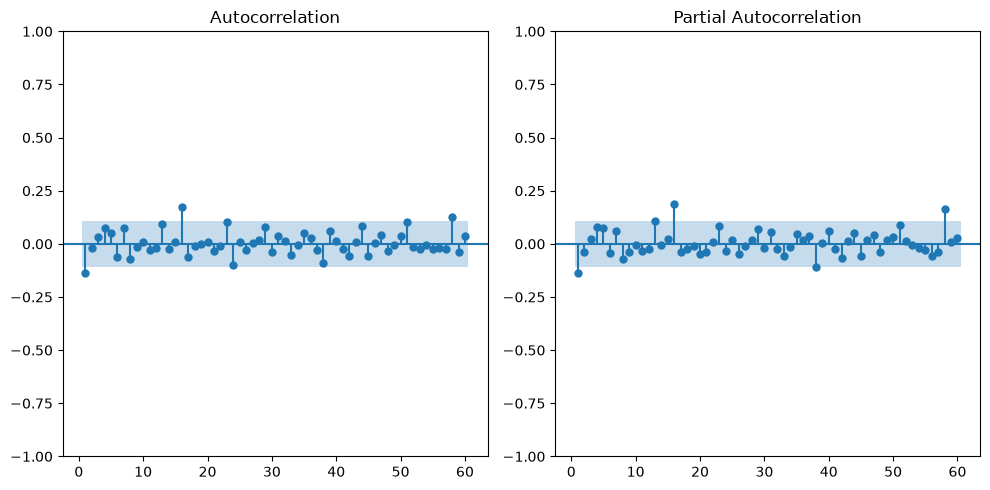

In [7]:
fig, ax = plt.subplots(1,2, figsize=(10,5))

plot_acf(pepsi_agregado['UNIDADES'], lags=60, ax=ax[0], zero=False, bartlett_confint=False)
plot_pacf(pepsi_agregado['UNIDADES'], lags=60, ax=ax[1], zero=False)

plt.tight_layout()
plt.show()

El `ACF` y `PACF` de la demanda son prácticamente planos, casi todas las autocorrelaciones caen dentro de la banda de significancia. Esto nos lleva a que la demanda de Pepsi, apenas es explicada por su propio pasado, lo que confirma el principal elemento de la serie no es la inercia temporal, sino el precio y la promoción, tal cómo se ha podido comprobar en el cálculo de la elasticidad y descomposición `STL`. En consecuencia, los lags de demanda se incluirán como predictores menores y se anticipa que los modelos basados solo en valores pasados de la serie (los que se emplearán como benchmark) tendrán un rendimiento pobre frente a modelos que incorporen el precio.

## Feature Engineering


In [8]:
pepsi_agregado = pepsi_agregado.sort_values('start').reset_index(drop=True)

# Incorporamos lags a la serie
for lag in [1,2,4]:
    pepsi_agregado[f'lag_{lag}'] = pepsi_agregado['UNIDADES'].shift(lag) # desplazamos demanda una semana

# Features calendario
pepsi_agregado['WEEK_YEAR'] = pepsi_agregado['start'].dt.isocalendar().week.astype(int)
pepsi_agregado['MES'] = pepsi_agregado['start'].dt.month

Al generar los lags también se generan valores nulos en las primeras semanas de la serie. Estos valores nulos realmente existen, ya que estamos trabajando con la serie recortada, eliminando los primeros años de la serie, debido a la inestabilidad que proporcionaban estos primeros años en cuanto a la cobertura por tiendas. Se podría reconstruir todo de 0 para no tener valores ausentes, pero como su impacto es marginal, vamos a dejar los valores vacíos.

## Benchmark

Antes de entrenar el modelo de ML se establece un conjunto de modelos de referencia que solo usan el pasado de la demanda, sin información de precio. Sirven como referencia: si el modelo con precio no los supera, no estaría aportando valor. 

- **Naive:** predice que la demanda será igual a la de la última semana observada.
- **Seasonal Naive:** predice que será igual a la de la misma semana del año anterior.
- **AutoETS:** suavizado exponencial con la configuración (tendencia, estacionalidad) elegida automáticamente por criterios estadísticos.

Todos se evalúan con backtesting de origen deslizante (13 ventanas, horizonte de 4 semanas) sobre el conjunto de entrenamiento, reservando el último año como test final intacto. La métrica principal es el MAE, acompañada del RMSE.

In [9]:
FIN_TRAIN = '1996-05-01'

train = pepsi_agregado[pepsi_agregado['start'] <= FIN_TRAIN].copy()
test = pepsi_agregado[pepsi_agregado['start'] > FIN_TRAIN].copy()

print(f'Inicio Train: {train["start"].min()}; Fin Train: {train["start"].max()}')
print(f'Inicio Test: {test["start"].min()}; Fin Test: {test["start"].max()}')

Inicio Train: 1991-01-03 00:00:00; Fin Train: 1996-04-25 00:00:00
Inicio Test: 1996-05-02 00:00:00; Fin Test: 1997-05-01 00:00:00


In [10]:
# Preparación de serie para statsforecast
train_sf = (train[['start', 'UNIDADES']]
                     .rename(columns={'start': 'ds', 'UNIDADES': 'y'})
                     .copy())

train_sf['unique_id'] = 'pepsi'

print(train_sf.shape)
train_sf.head()

(269, 3)


,ds,y,unique_id
0,1991-01-03,188.088608,pepsi
1,1991-01-10,403.087500,pepsi
2,1991-01-17,156.365854,pepsi
3,1991-01-24,158.629630,pepsi
4,1991-01-31,293.365854,pepsi


In [11]:
# Creamos modelos
modelos = [
    Naive(), # predecimos último valor observado
    SeasonalNaive(season_length=52), # Predice mismo valor del año pasado
    AutoETS(season_length=52)
]

# Instanciamos modelos
sf = StatsForecast(
    models=modelos,
    freq='7D',
    n_jobs=-1
)

# Creamos backtesting
cv_sf = sf.cross_validation(
    df=train_sf,
    h=4, # predicción a 4 semanas
    step_size=4, # pasos que avanza
    n_windows=13 # ventanas por las que desplazarse (medido en semanas)
)

print(cv_sf.columns.tolist())
cv_sf.head()

['unique_id', 'ds', 'cutoff', 'y', 'Naive', 'SeasonalNaive', 'AutoETS']


,unique_id,ds,cutoff,y,Naive,SeasonalNaive,AutoETS
0,pepsi,1995-05-04,1995-04-27,78.6125,118.1125,724.678571,210.767553
1,pepsi,1995-05-11,1995-04-27,341.1000,118.1125,85.523810,209.933482
2,pepsi,1995-05-18,1995-04-27,93.1625,118.1125,397.404762,209.099410
3,pepsi,1995-05-25,1995-04-27,287.5750,118.1125,179.380952,208.265338
4,pepsi,1995-06-01,1995-05-25,205.3375,287.5750,75.666667,335.174942


In [12]:
modelos_cols = ['Naive', 'SeasonalNaive', 'AutoETS']

resultados = pd.DataFrame({
    'Modelo': modelos_cols,
    'MAE' : [mean_absolute_error(cv_sf['y'], cv_sf[m]) for m in modelos_cols],
    'RMSE': [mean_squared_error(cv_sf['y'], cv_sf[m]) ** 0.5 for m in modelos_cols]
}).sort_values('MAE').reset_index(drop=True)

resultados

,Modelo,MAE,RMSE
0,AutoETS,260.204821,346.022416
1,SeasonalNaive,268.496289,448.893333
2,Naive,319.976108,444.818524


In [13]:
fig = go.Figure()

# Real primero, en negro y grueso
fig.add_trace(go.Scatter(
    x=cv_sf["ds"], y=cv_sf["y"],
    name="Real", line=dict(color="black", width=3)
))

# Cada modelo
for m in ["Naive", "SeasonalNaive", "AutoETS"]:
    fig.add_trace(go.Scatter(
        x=cv_sf["ds"], y=cv_sf[m],
        name=m, line=dict(width=1.5), opacity=0.8
    ))

fig.update_layout(
    title="Benchmark: predicciones vs demanda real (backtesting)",
    xaxis_title="fecha",
    yaxis_title="unidades / tienda",
    hovermode="x unified",     # muestra todos los valores de una fecha al pasar el ratón
    template="plotly_white",
    height=500,
)
fig.show()

Los modelos presentan unos resultados bastante pobres (MAE entre 260 y 320 unidades por tienda). El mejor es AutoETS (MAE 260), seguido de Seasonal Naive y Naive.

Ningún modelo temporal predice bien esta serie, algo que era esperable tras como fue la descomposición STL. El ACF ya anticipaba que la demanda apenas se explica por su propio pasado. Sin conocer el precio, estos modelos están "ciegos" ante el factor que realmente mueve la demanda.

El contraste MAE–RMSE es revelador. El Seasonal Naive tiene un MAE similar al de AutoETS (268 vs 260) pero un RMSE muy superior (449 vs 346): comete errores catastróficos puntuales al arrastrar los picos promocionales del año anterior a semanas en las que no hubo promoción. AutoETS falla de forma más consistente. Es un buen ejemplo de por qué conviene mirar ambas métricas.

Este MAE de 260 es el listón que el modelo con features de precio deberá batir.